# Day 34 — Jupyter Best Practices & DS Project Structure

**Phase 2: Data Tools · Day 34 of 94**

## Objective

- Learn the notebook structure recruiters and teammates actually expect to see
- Practice keeping **one concept per cell** instead of cramming logic together
- Use Markdown cells to explain *why*, not just *what*
- Set up a clean DS project folder structure (`data/`, `notebooks/`, `src/`, `outputs/`)
- Apply all of it to a real mini EDA pass on the FC Lahore Lions squad dataset

In [1]:
# Imports — always their own cell, always at the top
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# consistent style for all plots in this notebook
plt.style.use("seaborn-v0_8-darkgrid")

## Theory — What "Notebook Best Practices" Actually Means

**The standard notebook flow (top to bottom, every time):**
1. Title (Markdown) → what this notebook is
2. Objective (Markdown) → what you're trying to find out
3. Imports (Code) → all libraries, one cell, nothing scattered later
4. Theory / Why (Markdown) → the concept, in plain words, before any code touches it
5. Examples (Code, split up) → one idea per cell
6. Practice / Mini Challenge → you apply it yourself
7. Summary (Markdown) → 3–5 bullet takeaways

**The 3 rules that actually get checked in interviews:**
- 🔹 **One concept per cell.** If you can't describe a cell in one sentence, split it.
- 🔹 **Restart & Run All before you push.** (In Colab: `Runtime → Restart session and run all`.) This catches hidden state bugs — code that only works because of the order you happened to run cells in, not because the logic is actually correct top-to-bottom.
- 🔹 **Comment the *why*, not the *what*.** `# convert to numeric` tells a reviewer nothing. `# stored as object due to '-' placeholders for missing matches` tells them you understood the data.

**Folder structure (set this up before you write a single cell):**
```
project-name/
├── data/         → raw & cleaned CSVs (gitignored if raw)
├── notebooks/    → this file lives here
├── src/          → reusable functions, once a project grows past one notebook
├── outputs/      → saved plots, exported results
└── README.md
```

## Example 1 — The Messy Way (what *not* to do)

This is the kind of cell that gets a notebook rejected in review — everything jammed together, no markdown, no explanation:

```python
import pandas as pd
df=pd.read_csv('data.csv')
df=df.dropna()
df['goals']=df['goals'].astype(int)
print(df.describe())
df2=df[df['goals']>10]
df2.plot()
```

Problems: 4 different concepts in one cell (load → clean → transform → filter → plot), no comments, no markdown explaining intent, variable names (`df2`) that mean nothing to a reader six months from now.

## Example 2 — The Clean Way (applied to FC Lahore Lions data)

Same logic as above — split into one concept per cell, each with a short "why" before it.

In [2]:
# Why: start every EDA by creating/loading the dataset in its own cell
# FC Lahore Lions squad data — synthetic, seed=42 for reproducibility (same dataset used all through Phase 2)
np.random.seed(42)

n_players = 20
lahore_lions = pd.DataFrame({
    "player": [f"Player_{i+1}" for i in range(n_players)],
    "position": np.random.choice(["Forward", "Midfielder", "Defender", "Goalkeeper"], n_players),
    "matches_played": np.random.randint(5, 30, n_players),
    "goals": np.random.randint(0, 15, n_players),
    "assists": np.random.randint(0, 10, n_players),
    "yellow_cards": np.random.randint(0, 6, n_players),
})

lahore_lions.head()

,player,position,matches_played,goals,assists,yellow_cards
0,Player_1,Defender,26,6,1,5
1,Player_2,Goalkeeper,25,3,3,3
2,Player_3,Forward,6,8,6,5
3,Player_4,Defender,28,2,7,5
4,Player_5,Defender,16,4,2,3


**Why this next cell exists:** before touching the data, always check shape and dtypes — this is where you catch a numeric column accidentally stored as text.

In [3]:
lahore_lions.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   player          20 non-null     str  
 1   position        20 non-null     str  
 2   matches_played  20 non-null     int64
 3   goals           20 non-null     int64
 4   assists         20 non-null     int64
 5   yellow_cards    20 non-null     int64
dtypes: int64(4), str(2)
memory usage: 1.1 KB


**Why this next cell exists:** missing-value check gets its own cell — it's a decision point (drop? fill? flag?), not just a line to skim past.

In [4]:
lahore_lions.isnull().sum()

player            0
position          0
matches_played    0
goals             0
assists           0
yellow_cards      0
dtype: int64

**Why this next cell exists:** `.describe()` is the fastest sanity check for outliers or impossible values (e.g. negative goals) — it earns its own cell because it's a checkpoint, not just output.

In [5]:
lahore_lions.describe()

,matches_played,goals,assists,yellow_cards
count,20.00000,20.000000,20.000000,20.000000
mean,18.30000,5.800000,4.050000,3.050000
std,7.39203,3.396593,2.981963,1.731291
min,5.00000,1.000000,0.000000,0.000000
25%,15.50000,3.000000,1.000000,2.500000
50%,19.00000,6.000000,3.000000,3.500000
75%,25.00000,8.000000,6.250000,4.000000
max,29.00000,13.000000,9.000000,5.000000


**Why this next cell exists:** one plot, one purpose — a quick visual gut-check on the goals distribution before any deeper analysis. Plotting logic never shares a cell with data prep.

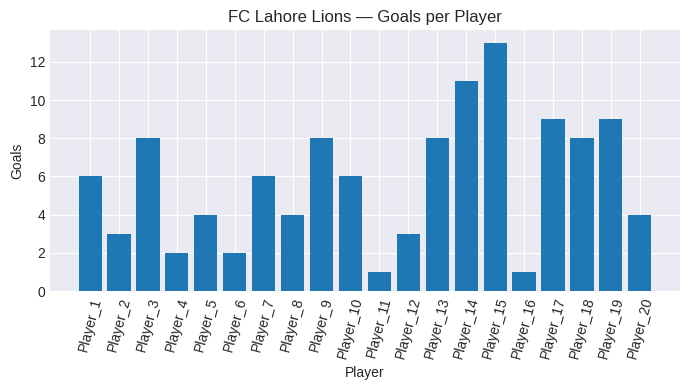

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(lahore_lions["player"], lahore_lions["goals"], color="#1f77b4")
ax.set_title("FC Lahore Lions — Goals per Player")
ax.set_xlabel("Player")
ax.set_ylabel("Goals")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("outputs/day34_goals_per_player.png", dpi=120)
plt.show()

## Practice Exercise

Below is a **messy cell** (same anti-pattern as Example 1, applied to this dataset). Your task: split it into 3 clean cells in the empty cell underneath — one for filtering, one for grouping, one for the printed result. Add a one-line markdown "why" above each.

```python
forwards = lahore_lions[lahore_lions['position'] == 'Forward']
avg_goals_by_position = lahore_lions.groupby('position')['goals'].mean()
print(avg_goals_by_position)
```

In [7]:
# Your turn — split the cell above into 3 clean cells right here.
# Cell 1: filter forwards
# Cell 2: group by position and average goals
# Cell 3: print/display the result


## Mini Challenge — Build Your DS Project Folder Structure

Run the cell below to scaffold the standard folder structure locally. This works the same in Colab as it does in Jupyter — the only difference is *where* it lives (Colab's runtime is temporary, so this only matters once it's connected to a repo).

In [8]:
# Build the standard DS project folders
for folder in ["data", "notebooks", "src", "outputs"]:
    os.makedirs(folder, exist_ok=True)

print("Folder structure ready:", os.listdir("."))

Folder structure ready: ['src', 'render.py', 'day_33_readme_bio.png', 'build_notebook.py', 'day_33_git_workflow.png', 'day_33_repo_structure.png', 'notebooks', 'day_34_jupyter_best_practices.ipynb', 'outputs', 'template.html', 'data', 'day_33_gitignore.png']


**Colab-specific note — since there's no persistent local filesystem:**

Two ways to connect this notebook to your Day 33 GitHub workflow:

- **Quick path:** `File → Save a copy in GitHub` (from the Colab menu) — fast, but you don't control the commit message wording as precisely.
- **Full-control path (matches the Day 33 workflow exactly):** clone your repo into the Colab session, work inside that cloned folder, then commit/push from a code cell:

```python
!git clone https://github.com/<your-username>/<your-repo>.git
%cd <your-repo>
# ...do your work inside this folder...
!git add .
!git commit -m "Day 34: Jupyter/Colab best practices + FC Lahore Lions EDA"
!git push origin main
```

Either way — make sure the `.gitignore` from Day 33 (`.ipynb_checkpoints/`, `__pycache__/`, `data/*.csv`, `.env`) is already in the repo before you push.

## Summary

- ✅ A notebook's structure (Title → Objective → Imports → Theory → Examples → Practice → Summary) is not decoration — it's what makes a stranger able to follow your thinking
- ✅ One concept per cell makes debugging faster and reviews easier — bundled cells hide bugs and hide understanding
- ✅ `Restart & Run All` (or Colab's `Restart session and run all`) before every push — this is the #1 thing that separates "looks done" from "actually works"
- ✅ Comments should explain *why* a decision was made, not restate the code
- ✅ Folder structure (`data/`, `notebooks/`, `src/`, `outputs/`) should exist before the first cell is written, not after
- ✅ Colab has no persistent filesystem — the GitHub repo *is* the real home for the project, not the Colab session